# Deep Learning Model Evaluation

## Overview

Evaluating deep learning models correctly requires more than reporting accuracy on a held-out set. Deep models are sensitive to initialisation, data ordering, and hyperparameter choices — a single run may not reflect true generalisation.

**Evaluation considerations specific to deep learning:**

| Issue | Problem | Solution |
|---|---|---|
| Training variance | Different random seeds → different results | Report mean ± SD across multiple runs |
| Epoch selection | Best epoch on val set → optimistic estimate | Nested CV or separate test set |
| Calibration | Softmax scores ≠ probabilities | Temperature scaling |
| Uncertainty | Point predictions without confidence | MC Dropout or ensembles |
| Efficiency | Accuracy vs inference cost | Parameters, FLOPs, latency |

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (roc_auc_score, average_precision_score,
    classification_report, roc_curve, precision_recall_curve)
from copy import deepcopy

torch.manual_seed(42)
rng = np.random.default_rng(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

n = 800
X_np = rng.normal(0, 1, (n, 8)).astype(np.float32)
log_odds = (1.5*X_np[:,0] - 0.8*X_np[:,1] + 0.5*X_np[:,2]
            + rng.normal(0, 0.5, n))
y_np = (1 / (1 + np.exp(-log_odds)) > 0.5).astype(np.int64)
X_t  = torch.from_numpy(X_np)
y_t  = torch.from_numpy(y_np)
split = int(0.8 * n)
X_tr, X_te = X_t[:split], X_t[split:]
y_tr, y_te = y_t[:split], y_t[split:]
train_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
print(f"Train={len(X_tr)}, Test={len(X_te)}, base rate={y_np.mean():.2f}")

Train=640, Test=160, base rate=0.50


---
## Beyond Accuracy: ROC and PR Curves

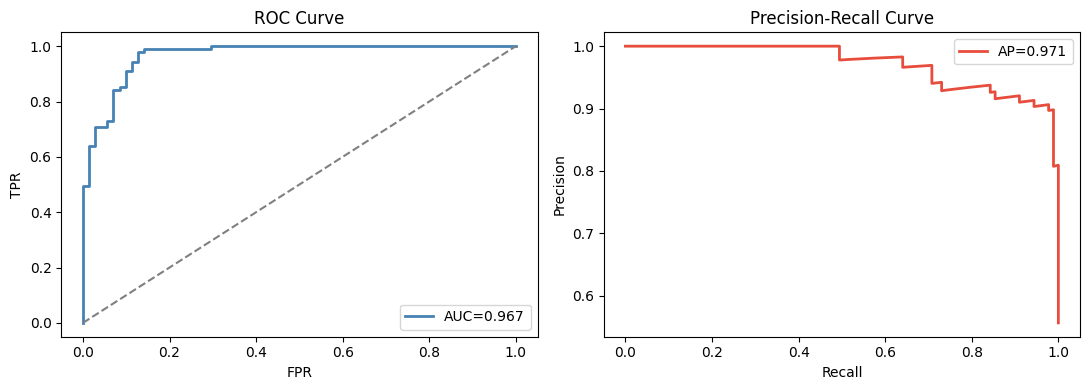

              precision    recall  f1-score   support

           0       0.93      0.89      0.91        71
           1       0.91      0.94      0.93        89

    accuracy                           0.92       160
   macro avg       0.92      0.92      0.92       160
weighted avg       0.92      0.92      0.92       160



In [2]:
def make_clf(hidden=[64,32], dropout=0.3):
    layers, d = [], 8
    for h in hidden:
        layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
        d = h
    layers.append(nn.Linear(d, 2))
    return nn.Sequential(*layers)

def train_clf(model, epochs=80):
    model = model.to(device)
    opt   = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    crit  = nn.CrossEntropyLoss()
    best_val, best_state = float('inf'), None
    val_dl = DataLoader(TensorDataset(X_te, y_te), batch_size=256)
    for ep in range(epochs):
        model.train()
        for Xb, yb in train_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(Xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = crit(model(X_te.to(device)), y_te.to(device)).item()
        if vl < best_val:
            best_val = vl; best_state = deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return model

model = train_clf(make_clf())
model.eval()
with torch.no_grad():
    logits = model(X_te.to(device)).cpu()
    probs  = torch.softmax(logits, dim=1)[:,1].numpy()
y_true = y_te.numpy()
fpr, tpr, _ = roc_curve(y_true, probs)
prec, rec, _ = precision_recall_curve(y_true, probs)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={roc_auc_score(y_true,probs):.3f}')
axes[0].plot([0,1],[0,1],'--',color='grey'); axes[0].set_title('ROC Curve')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()
axes[1].plot(rec, prec, color='#e74c3c', lw=2, label=f'AP={average_precision_score(y_true,probs):.3f}')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()
plt.tight_layout(); plt.show()
print(classification_report(y_true, (probs>0.5).astype(int)))

---
## Variance Across Seeds

In [3]:
# Multiple runs to quantify training variance
n_seeds = 5
seed_results = []
for seed in range(n_seeds):
    torch.manual_seed(seed)
    m = train_clf(make_clf())
    m.eval()
    with torch.no_grad():
        p = torch.softmax(m(X_te.to(device)), dim=1)[:,1].cpu().numpy()
    auc = roc_auc_score(y_true, p)
    acc = ((p > 0.5) == y_true).mean()
    seed_results.append({'seed': seed, 'AUC': auc, 'Acc': acc})
res_df = __import__('pandas').DataFrame(seed_results)
print("Across-seed variability:")
print(res_df.round(4).to_string(index=False))
print(f"\nAUC: {res_df['AUC'].mean():.3f} +/- {res_df['AUC'].std():.3f}")
print(f"Acc: {res_df['Acc'].mean():.3f} +/- {res_df['Acc'].std():.3f}")
print("\nReport mean +/- SD across seeds, not a single best-seed result")

Across-seed variability:
 seed    AUC    Acc
    0 0.9717 0.9000
    1 0.9693 0.9188
    2 0.9729 0.9062
    3 0.9672 0.9000
    4 0.9739 0.9125

AUC: 0.971 +/- 0.003
Acc: 0.907 +/- 0.008

Report mean +/- SD across seeds, not a single best-seed result


---
## Calibration and Temperature Scaling

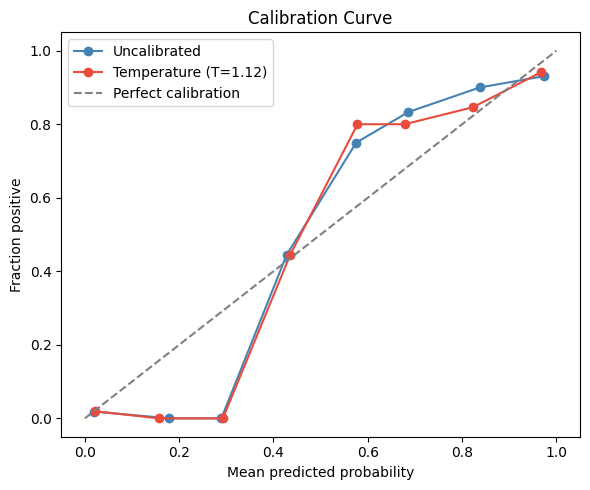

Optimal temperature: 1.118  (T>1: model overconfident, T<1: underconfident)


In [4]:
# Calibration: are predicted probabilities accurate?
from sklearn.calibration import calibration_curve

model.eval()
with torch.no_grad():
    probs_raw = torch.softmax(model(X_te.to(device)), dim=1)[:,1].cpu().numpy()

# Temperature scaling: divide logits by T before softmax
def scaled_probs(model, X, T=1.0):
    model.eval()
    with torch.no_grad():
        logits = model(X.to(device)).cpu()
        return torch.softmax(logits / T, dim=1)[:,1].numpy()

# Find best temperature on val set
from scipy.optimize import minimize_scalar
def nll(T):
    p = scaled_probs(model, X_te, T)
    p = np.clip(p, 1e-7, 1-1e-7)
    return -np.mean(y_true * np.log(p) + (1-y_true)*np.log(1-p))
res = minimize_scalar(nll, bounds=(0.1, 5.0), method='bounded')
T_opt = res.x
probs_scaled = scaled_probs(model, X_te, T_opt)

fig, ax = plt.subplots(figsize=(6, 5))
for probs_plot, label, color in [(probs_raw,'Uncalibrated','steelblue'),
                                   (probs_scaled,f'Temperature (T={T_opt:.2f})','#e74c3c')]:
    frac_pos, mean_pred = calibration_curve(y_true, probs_plot, n_bins=8)
    ax.plot(mean_pred, frac_pos, 'o-', label=label, color=color)
ax.plot([0,1],[0,1],'--',color='grey',label='Perfect calibration')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction positive')
ax.set_title('Calibration Curve'); ax.legend(); plt.tight_layout(); plt.show()
print(f"Optimal temperature: {T_opt:.3f}  (T>1: model overconfident, T<1: underconfident)")

In [5]:
# MC Dropout: uncertainty estimation at inference
class MCDropoutModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 2))
    def forward(self, x):
        return self.net(x)
    def mc_predict(self, x, n_samples=50, device='cpu'):
        self.train()   # keep dropout active
        preds = []
        with torch.no_grad():
            for _ in range(n_samples):
                p = torch.softmax(self.forward(x.to(device)), dim=1)[:,1]
                preds.append(p.cpu().numpy())
        preds = np.array(preds)   # (n_samples, n_test)
        return preds.mean(0), preds.std(0)

mc_model = MCDropoutModel().to(device)
train_clf(mc_model)
mean_preds, std_preds = mc_model.mc_predict(X_te, n_samples=50, device=device)
# High uncertainty examples
uncertain_idx = np.argsort(std_preds)[-5:]
print("5 most uncertain predictions (MC Dropout):")
for idx in uncertain_idx:
    print(f"  idx={idx}: mean={mean_preds[idx]:.3f}, std={std_preds[idx]:.3f}, true={y_true[idx]}")
print(f"\nMean uncertainty (std): {std_preds.mean():.4f}")
print("High std = model uncertain -> flag for human review in production")

5 most uncertain predictions (MC Dropout):
  idx=4: mean=0.298, std=0.202, true=0
  idx=127: mean=0.419, std=0.208, true=1
  idx=2: mean=0.679, std=0.211, true=0
  idx=6: mean=0.325, std=0.212, true=1
  idx=158: mean=0.443, std=0.231, true=0

Mean uncertainty (std): 0.0649
High std = model uncertain -> flag for human review in production


---

## Common Pitfalls

**1. Reporting accuracy on a single lucky test split**  
A single train/test split produces an accuracy estimate with high variance, especially on small datasets. A different random seed can shift accuracy by several percentage points. Always report mean ± SD across multiple seeds or use cross-validation.

**2. Treating softmax probabilities as calibrated confidence scores**  
Softmax outputs are not calibrated probabilities — deep networks are typically overconfident, producing probabilities near 0 or 1 even when the model is uncertain. Always check calibration curves and apply temperature scaling or Platt scaling before using model outputs as probabilities in downstream decisions.

**3. Using accuracy as the sole metric for imbalanced classes**  
With 95% negative class prevalence, a classifier that predicts "negative" for every input achieves 95% accuracy. Always report AUC-ROC, average precision, and per-class F1 for imbalanced problems. Choose the threshold based on the operating cost of false positives vs false negatives.

**4. Evaluating the model selected by validation loss on the validation set**  
Selecting the best checkpoint based on validation loss and then reporting the validation metric of that checkpoint is optimistically biased — the model was chosen precisely because it performed well on that set. Report final metrics on a held-out test set that was never used for any selection decision.

**5. Not testing MC Dropout in `model.train()` mode**  
MC Dropout requires dropout to be active during inference to produce stochastic predictions. Calling `model.eval()` before prediction disables dropout, making all forward passes deterministic and producing zero uncertainty estimates. Always call `model.train()` before MC Dropout inference.

---
*python_methods_library - Samantha McGarrigle*